In [204]:
import math
import numpy as np
from scipy.ndimage import gaussian_filter

import rasterio
from rasterio.windows import Window

def blur(image: np.ndarray, psf_sigma: float, source_gsd: float, target_gsd: float) -> np.ndarray:
    """Apply Gaussian PSF blur scaled to the GSD ratio."""
    scale_factor = target_gsd / source_gsd
    sigma_pixels = psf_sigma * scale_factor
    blurred = np.empty_like(image, dtype=np.float64)
    for c in range(image.shape[0]):
        blurred[c] = gaussian_filter(image[c].astype(np.float64), sigma=sigma_pixels)
    return blurred
 
 
def noise(image: np.ndarray, snr_db: float) -> np.ndarray:
    """Add Poisson noise at a given SNR (dB)."""
    snr_linear = 10 ** (snr_db / 20)
    signal_power = np.mean(image.astype(np.float64) ** 2)
    noise_std = math.sqrt(signal_power) / snr_linear
    scale = 1.0 / (noise_std ** 2 + 1e-10)
    noisy = np.random.poisson(np.clip(image.astype(np.float64) * scale, 0, None))
    return noisy / scale
 
 
def downsample(image: np.ndarray, source_gsd: float, target_gsd: float) -> np.ndarray:
    """Average-pool downsample by the GSD ratio (integer scale)."""
    scale = int(round(target_gsd / source_gsd))
    if scale == 1:
        return image
    C, H, W = image.shape
    new_H = H // scale
    new_W = W // scale
    cropped = image[:, : new_H * scale, : new_W * scale]
    return cropped.reshape(C, new_H, scale, new_W, scale).mean(axis=(2, 4))


def extract_tile(source_image: str, min_x: float, max_x: float, 
                 min_y: float, max_y: float) -> tuple[np.ndarray, any]:
    """Extract a tile from the source image using rasterio."""
    with rasterio.open(source_image) as src:
        # src.index() returns (row, col)
        top, left = src.index(min_x, max_y)    # top-left corner
        bottom, right = src.index(max_x, min_y) # bottom-right corner
        width = right - left
        height = bottom - top
        window = Window(left, top, width, height)
        tile = src.read(window=window)
        transform = src.window_transform(window)
    return tile, transform

def convert_to_uint8(image: np.ndarray) -> np.ndarray:
    """Convert image to uint8 range [0, 255]."""
    max_val = image.max()
    min_val = image.min()
    if max_val == min_val:
        return np.zeros_like(image, dtype=np.uint8)
    scaled = (image - min_val) / (max_val - min_val) * 255
    return scaled.astype(np.uint8)


def apply_transform(source_image: str, transform_params: dict) -> tuple[np.ndarray, any]:

    min_x = transform_params.get("min_x")
    max_x = transform_params.get("max_x")
    min_y = transform_params.get("min_y")
    max_y = transform_params.get("max_y")
    psf_sigma = transform_params.get("psf_sigma")
    snr_db = transform_params.get("snr_db")
    order = transform_params.get("order")
    source_gsd = transform_params.get("source_gsd")
    target_gsd = transform_params.get("target_gsd")

    # extract tile using rasterio        
    tile, geometadata = extract_tile(source_image, min_x, max_x, min_y, max_y)

    # apply transformations
    for op in order:
        if op == "B":
            tile = blur(tile, psf_sigma, source_gsd, target_gsd)
        elif op == "N":
            tile = noise(tile, snr_db)
        elif op == "D":
            tile = downsample(tile, source_gsd, target_gsd)
        else:
            raise ValueError(f"Unknown operation '{op}' in order '{order}'")
    
    return tile, geometadata


image_id           IMG_PHR1A_PMS_202009041042188_ORT_5311355101.tif
tile_id                                                 19200_24320
min_x                                                     312675.25
max_x                                                     312995.25
min_y                                                    4802976.75
max_y                                                    4803296.75
tile_size_px                                                    640
length_x_meters                                               320.0
length_y_meters                                               320.0
native_crs                                               EPSG:32632
GSD_input                                                       0.5
GSD_output                                                     10.0
Transform_id                                                     12
Order                                                           BDN
SNR (dB)                                        

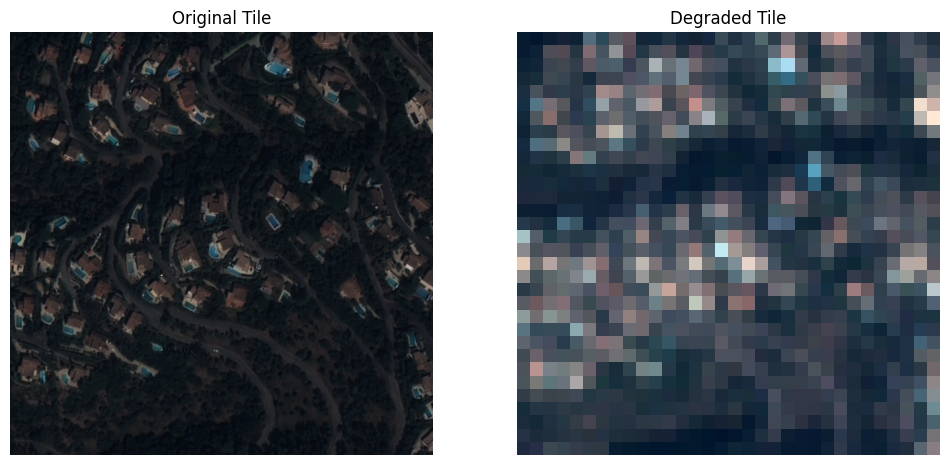

In [344]:
import pandas as pd
import matplotlib.pyplot as plt
import random


source_dir = "/home/luka/projects/boat-sat/data/phr/DONE"
source_csv = "/home/luka/projects/boat-sat/tile_mixture_assignments.csv"
df = pd.read_csv(source_csv) # select random rows for demonstration
# generate random seed
# keep Order "BDN" only

df = df[df["image_id"] == "IMG_PHR1A_PMS_202009041042188_ORT_5311355101.tif"]
# df = df[df["Transform_id"] == 2]
df = df[df["Order"] == "BDN"]
sample_rows = df.sample(n=1, random_state=random.randint(0, 10000))
# sample_rows = df[:20]

for _, row in sample_rows.iterrows():
    source_image = f"{source_dir}/{row['image_id']}"
    transform_params = {
        "min_x": row["min_x"],
        "max_x": row["max_x"],
        "min_y": row["min_y"],
        "max_y": row["max_y"],
        "psf_sigma": row["PSF"],
        "snr_db": row["SNR (dB)"],
        "order": row["Order"],
        "source_gsd": row["GSD_input"],
        "target_gsd": row["GSD_output"]
    }

    degraded_tile, geometadata = apply_transform(source_image, transform_params)
    print(row)
    original_tile, _ = extract_tile(source_image, transform_params["min_x"], transform_params["max_x"], transform_params["min_y"], transform_params["max_y"])

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(convert_to_uint8(original_tile[:3]).transpose(1, 2, 0))
    plt.title("Original Tile")
    plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.imshow(convert_to_uint8(degraded_tile[:3]).transpose(1, 2, 0))
    plt.title("Degraded Tile")
    plt.axis("off")
    plt.show()



